<a href="https://colab.research.google.com/github/Varshini151205/DL/blob/main/DL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)**

In [ ]:
import numpy as np

def step(x):
  return 1 if x>=0 else 0

class Perceptron:
  def __init__(self,weights,weight):
    self.weights=weights
    self.bias=bias

  def predict(self,x):
    return step(np.dot(x,self.weights)+self.bias)

weights=np.array([1,1])
bias=-1.5
and_gate=Perceptron(weights,bias)

print("and gate")

for x in [[0,0],[0,1],[1,0],[1,1]]:
  print(x,"--->",and_gate.predict(np.array(x)))



and gate
[0, 0] ---> 0
[0, 1] ---> 0
[1, 0] ---> 0
[1, 1] ---> 1


In [ ]:
weights=np.array([1,1])
bias=-0.1
or_gate=Perceptron(weights,bias)

print("or gate")

for x in [[0,0],[0,1],[1,0],[1,1]]:
  print(x,"-->",or_gate.predict(np.array(x)))

or gate
[0, 0] --> 0
[0, 1] --> 1
[1, 0] --> 1
[1, 1] --> 1


**Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.**

In [ ]:
import numpy as np

def step(x):
  return 1 if x>=0 else 0

class XOR_Network:
  def __init__(self):
    self.w_or=np.array([1,1])
    self.b_or=-0.5

    self.w_and=np.array([1,1])
    self.b_and=-1.5

    self.w_out=np.array([1,-2])
    self.b_out=-0.5

  def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)     # OR result
        h2 = step(np.dot(self.w_and, x) + self.b_and)  # AND result

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

# Test XOR gate
print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))




XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


**XNOR**

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class XNOR_Network:
    def __init__(self):

        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        self.w_nor = np.array([-1, -1])
        self.b_nor = 0.5

        self.w_out = np.array([1, 1])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_and, x) + self.b_and)   # AND
        h2 = step(np.dot(self.w_nor, x) + self.b_nor)   # NOR

        output = step(np.dot(self.w_out, [h1, h2]) + self.b_out)
        return output

xnor_gate = XNOR_Network()

print("XNOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xnor_gate.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


**Demonstrate that the thresholding logic used by perceptron is very harsh.**

In [1]:
import numpy as np

def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0

def perceptron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights) + bias
    output = step_function(weighted_sum)
    return weighted_sum, output

weights = [0.5, 0.5]
bias = -0.5

inputs1 = [0.49, 0.49]
inputs2 = [0.5, 0.5]

sum1, out1 = perceptron(inputs1, weights, bias)
sum2, out2 = perceptron(inputs2, weights, bias)

print("Input:", inputs1)
print("Weighted Sum:", sum1)
print("Output:", out1)

print("\nInput:", inputs2)
print("Weighted Sum:", sum2)
print("Output:", out2)

Input: [0.49, 0.49]
Weighted Sum: -0.010000000000000009
Output: 0

Input: [0.5, 0.5]
Weighted Sum: 0.0
Output: 1


**Demonstrate the Representation Power of a Network of Perceptrons
How many Boolean functions can be designed using two binary inputs?
For each Boolean function, determine whether it is linearly separable.

x1
x2
f1
f2
f3
f4
f5
f6
f7
f8
f9
f10
f11
f12
f13
f14
f15
f16
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
0
1
0
0
0
0
1
1
1
1
0
0
0
0
1
1
1
1
1
0
0
0
1
1
0
0
1
1
0
0
1
1
0
0
1
1
1
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1




Implement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why)
Extend the program to estimate or analyze how the number of non-linearly separable Boolean functions increases as the number of inputs n grows.
**

In [2]:
import numpy as np
import itertools

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

def train_perceptron(X, y, lr=0.1, epochs=20):
    weights = np.zeros(X.shape[1])
    bias = 0

    for _ in range(epochs):
        for xi, target in zip(X, y):
            z = np.dot(xi, weights) + bias
            y_pred = 1 if z >= 0 else 0
            error = target - y_pred

            weights += lr * error * xi
            bias += lr * error

    predictions = []
    for xi in X:
        z = np.dot(xi, weights) + bias
        predictions.append(1 if z >= 0 else 0)

    return predictions

functions = list(itertools.product([0,1], repeat=4))

learnable = 0
not_learnable = 0

for f in functions:
    preds = train_perceptron(X, np.array(f))
    if list(f) == preds:
        learnable += 1
    else:
        not_learnable += 1

print("Total Boolean Functions:", len(functions))
print("Learnable by Perceptron:", learnable)
print("Not Learnable:", not_learnable)

Total Boolean Functions: 16
Learnable by Perceptron: 14
Not Learnable: 2


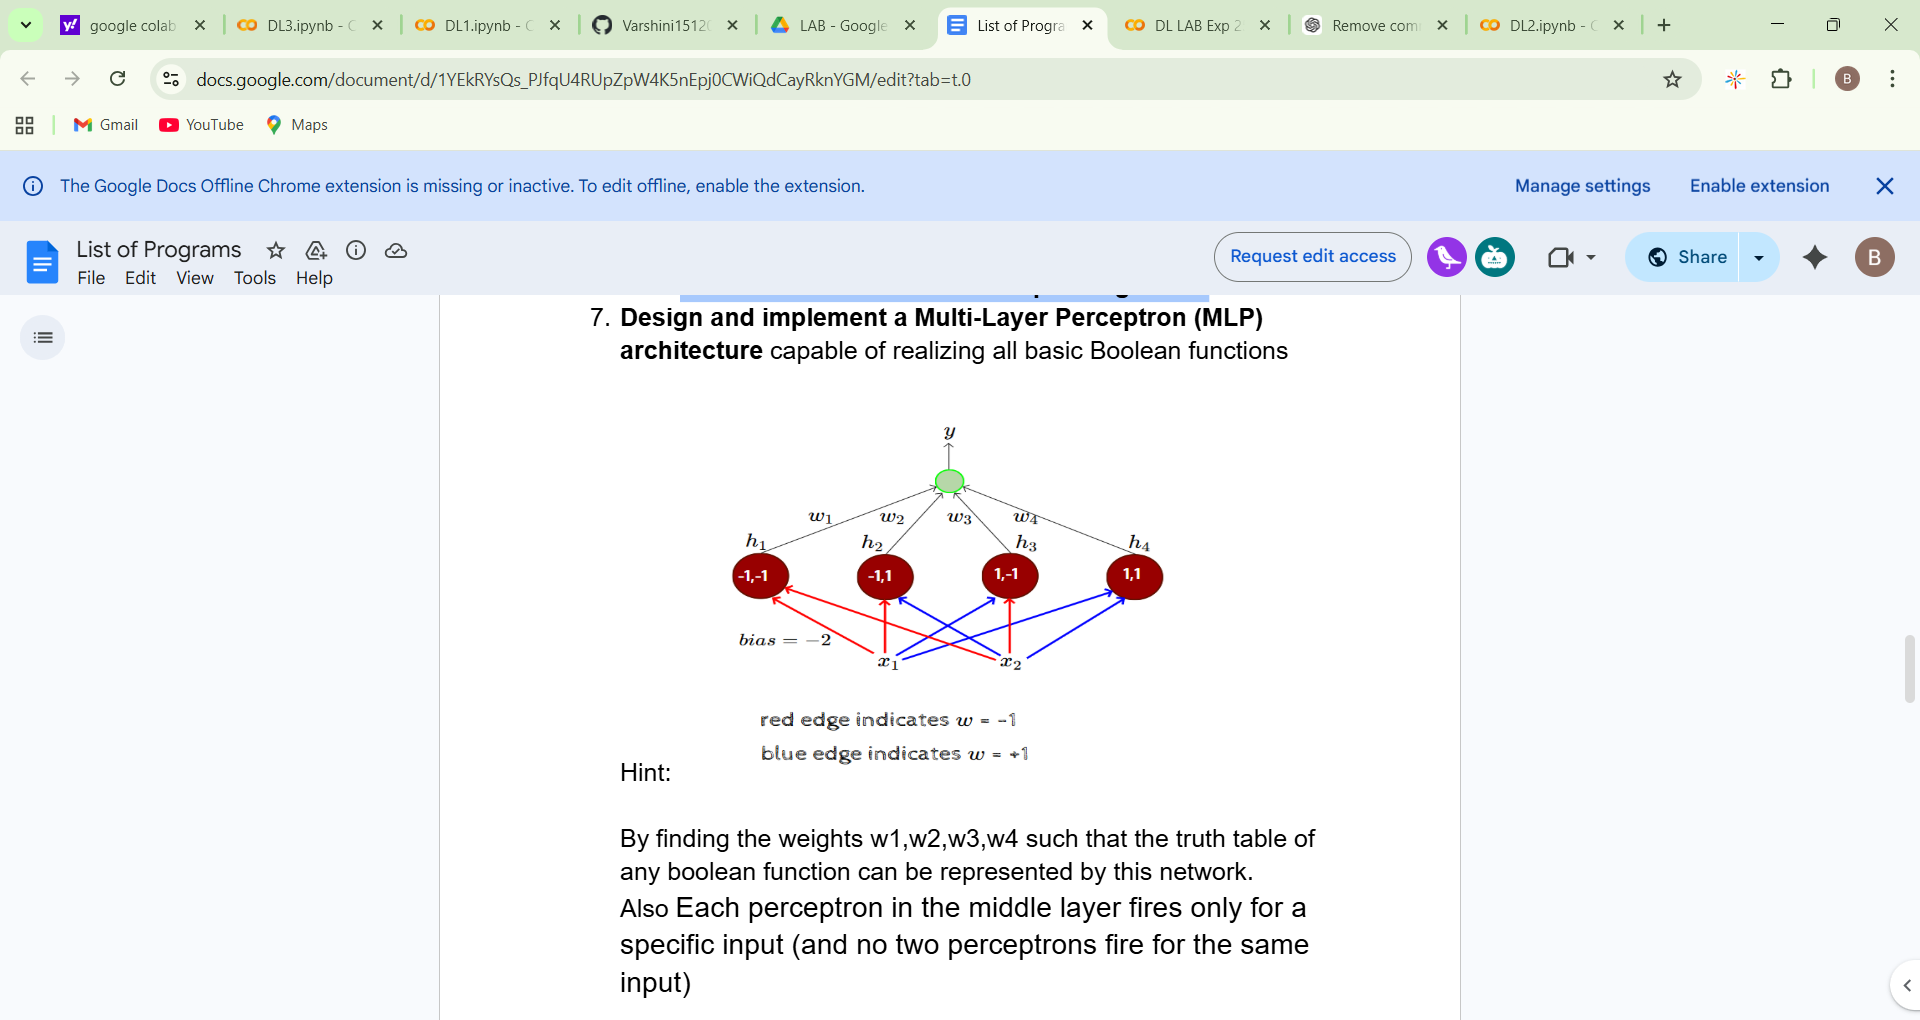

In [5]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1, x2):

    h1 = step(-x1 - x2 + 0.5)   # (0,0)
    h2 = step(-x1 + x2 - 0.5)   # (0,1)
    h3 = step(x1 - x2 - 0.5)    # (1,0)
    h4 = step(x1 + x2 - 1.5)    # (1,1)

    return np.array([h1, h2, h3, h4])


def mlp(x1, x2, weights, bias):

    h = hidden_layer(x1, x2)

    y = np.dot(weights, h) + bias

    return step(y)


weights = [0,1,1,0]   # XOR
bias = -0.5

inputs = [(0,0),(0,1),(1,0),(1,1)]

for x1,x2 in inputs:
    print(x1,x2,"->",mlp(x1,x2,weights,bias))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 0


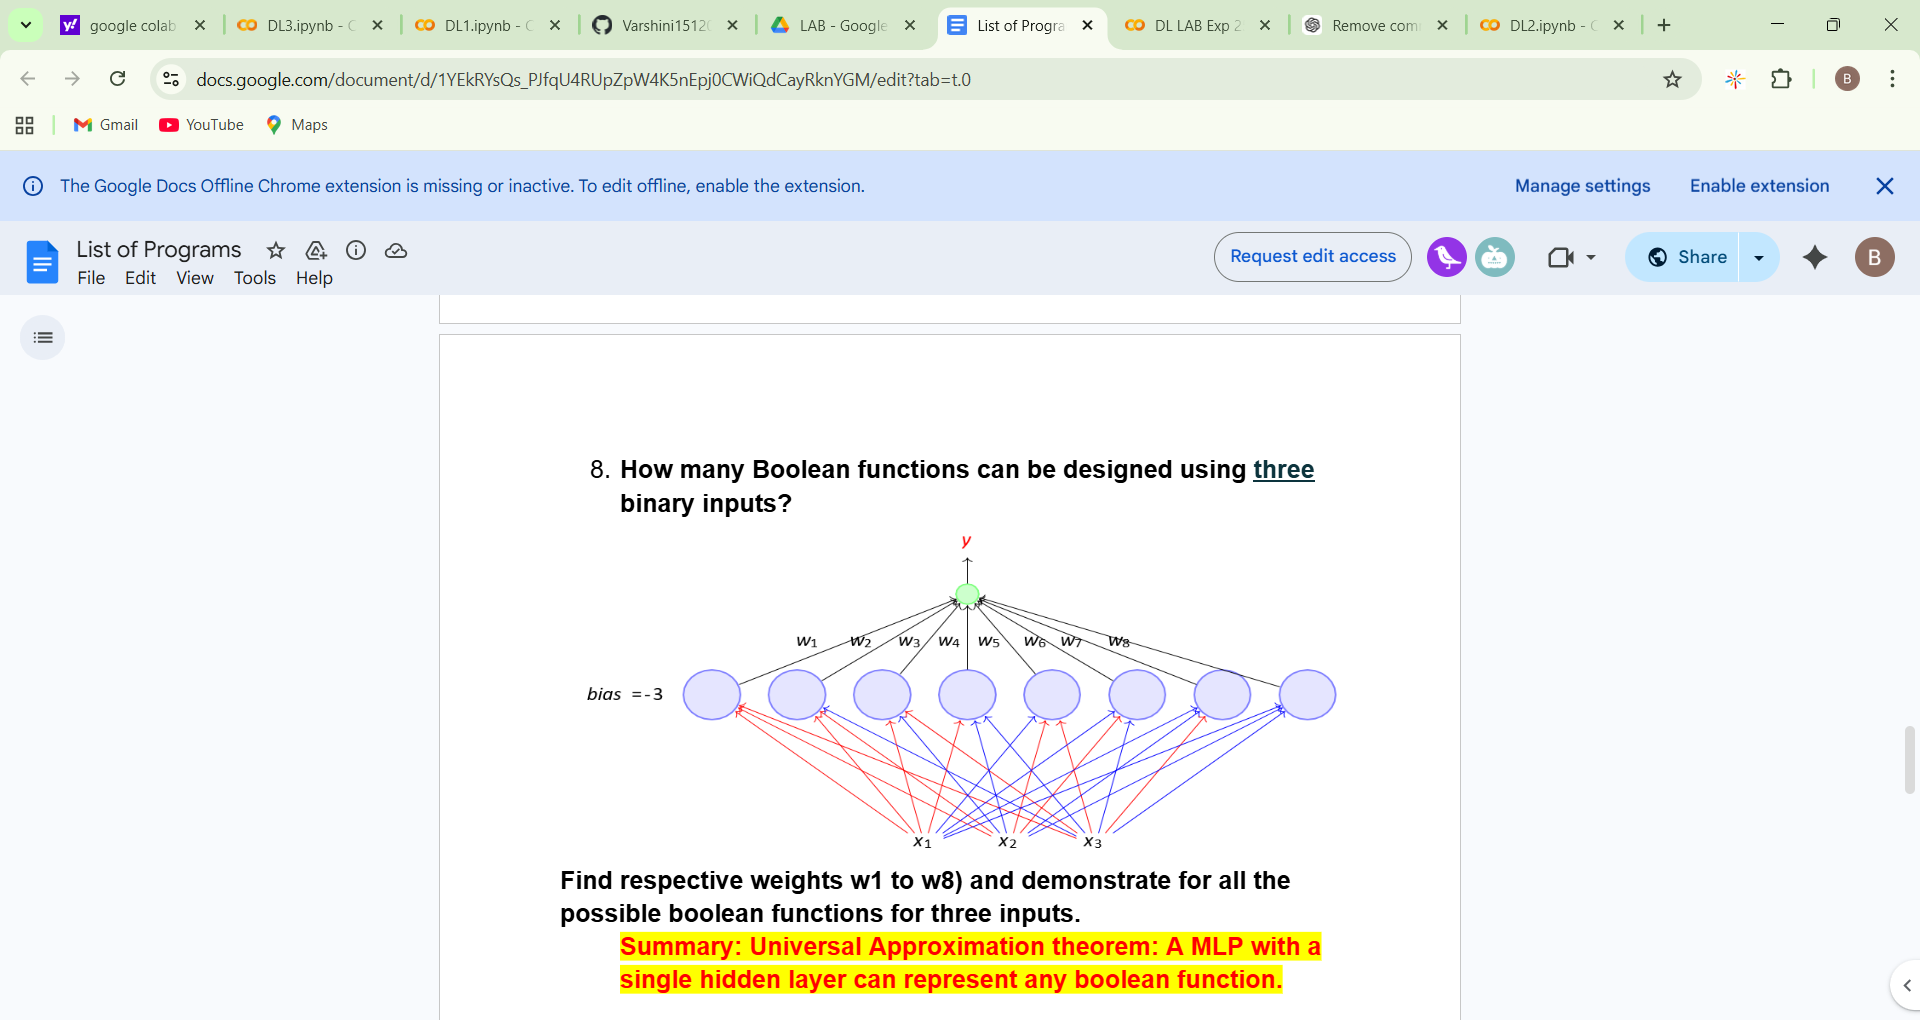

In [6]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1,x2,x3):

    h1 = step(-x1 -x2 -x3 +0.5)   #000
    h2 = step(-x1 -x2 +x3 -0.5)   #001
    h3 = step(-x1 +x2 -x3 -0.5)   #010
    h4 = step(-x1 +x2 +x3 -1.5)   #011
    h5 = step(x1 -x2 -x3 -0.5)    #100
    h6 = step(x1 -x2 +x3 -1.5)    #101
    h7 = step(x1 +x2 -x3 -1.5)    #110
    h8 = step(x1 +x2 +x3 -2.5)    #111

    return np.array([h1,h2,h3,h4,h5,h6,h7,h8])


def mlp(x1,x2,x3,weights,bias):

    h = hidden_layer(x1,x2,x3)

    y = np.dot(weights,h) + bias

    return step(y)


weights = [0,1,1,0,1,0,0,1]   # example function
bias = -0.5

inputs = [
(0,0,0),
(0,0,1),
(0,1,0),
(0,1,1),
(1,0,0),
(1,0,1),
(1,1,0),
(1,1,1)
]

for x1,x2,x3 in inputs:
    print(x1,x2,x3,"->",mlp(x1,x2,x3,weights,bias))

0 0 0 -> 0
0 0 1 -> 1
0 1 0 -> 1
0 1 1 -> 0
1 0 0 -> 1
1 0 1 -> 0
1 1 0 -> 0
1 1 1 -> 1
